# Crop Yield Prediction — Regression Analysis

**Dataset:** `crop_yield.csv` — per-field agricultural records (region, soil type, crop, weather conditions, and farming practices) with a continuous target, `Yield_tons_per_hectare`. This is a regression problem on agricultural data, not the house-price dataset used in class.

**Goal:** compare a gradient-descent linear model (`SGDRegressor`) against three other regression approaches — ordinary least squares (`LinearRegression`), a `DecisionTreeRegressor`, and a `RandomForestRegressor` — pick the best performer using a reproducible, data-driven criterion, and ship it as a saved model plus a standalone prediction script (`predict.py`).

In [16]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [17]:
df = pd.read_csv("crop_yield.csv")
df = df.sample(100000, random_state=42).reset_index(drop=True)
df.shape

(100000, 10)

In [18]:
df.info()
df.describe()
df.isnull().sum()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  100000 non-null  str    
 1   Soil_Type               100000 non-null  str    
 2   Crop                    100000 non-null  str    
 3   Rainfall_mm             100000 non-null  float64
 4   Temperature_Celsius     100000 non-null  float64
 5   Fertilizer_Used         100000 non-null  bool   
 6   Irrigation_Used         100000 non-null  bool   
 7   Weather_Condition       100000 non-null  str    
 8   Days_to_Harvest         100000 non-null  int64  
 9   Yield_tons_per_hectare  100000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 6.3 MB


Region                         4
Soil_Type                      6
Crop                           6
Rainfall_mm               100000
Temperature_Celsius        99999
Fertilizer_Used                2
Irrigation_Used                2
Weather_Condition              3
Days_to_Harvest               90
Yield_tons_per_hectare     99999
dtype: int64

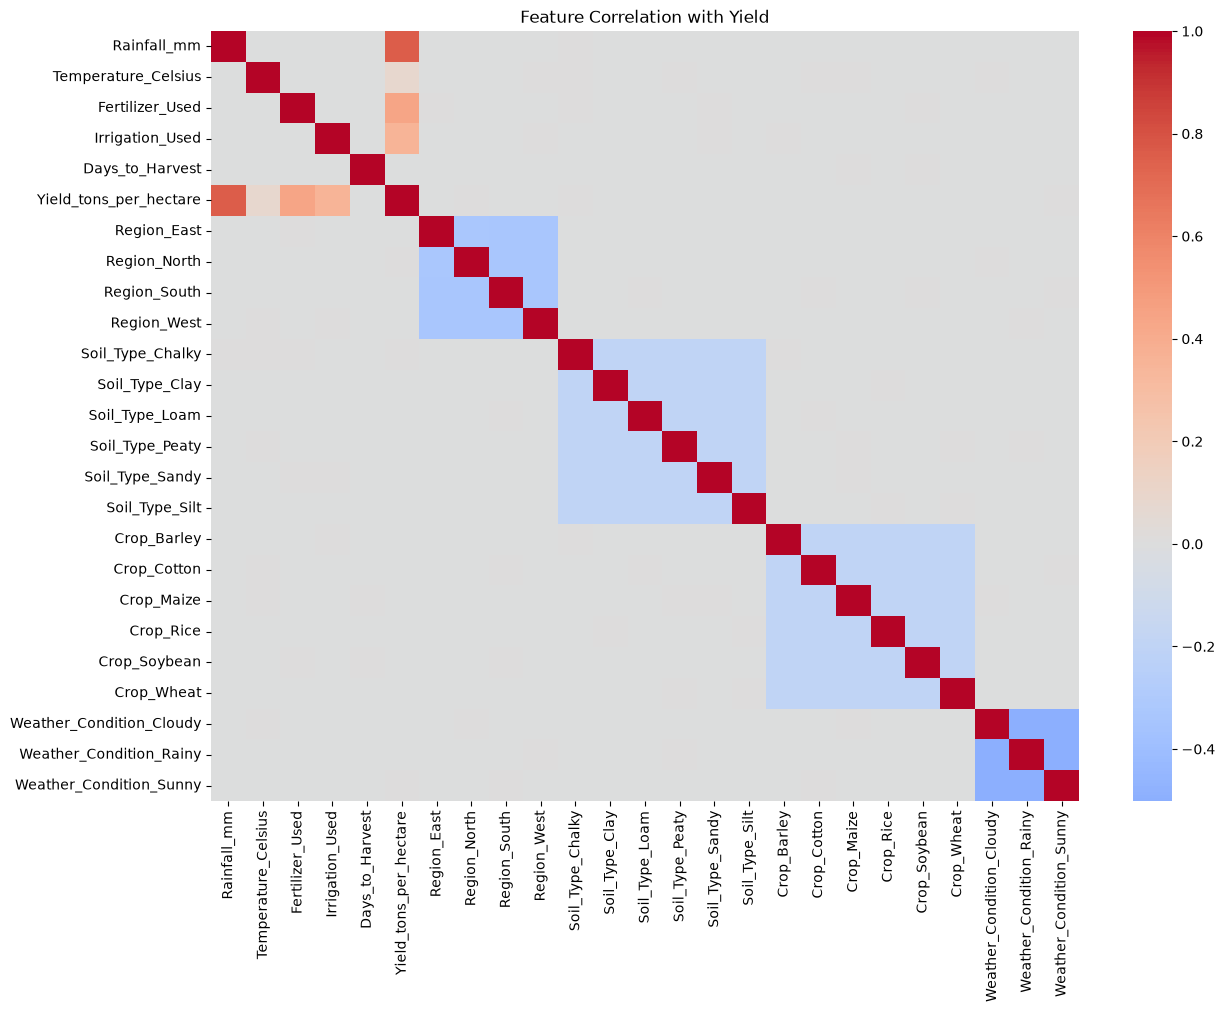

In [19]:
d = df.copy()
d['Fertilizer_Used'] = d['Fertilizer_Used'].astype(int)
d['Irrigation_Used'] = d['Irrigation_Used'].astype(int)
d = pd.get_dummies(d, columns=['Region','Soil_Type','Crop','Weather_Condition'])
plt.figure(figsize=(14,10))
sns.heatmap(d.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Yield'); plt.show()

**Correlation heatmap — interpretation.** `Rainfall_mm`, `Fertilizer_Used`, and `Irrigation_Used` show the strongest positive correlation with `Yield_tons_per_hectare`, which matches agronomic intuition — water and fertilizer availability are the main drivers of crop yield. `Days_to_Harvest` sits at essentially zero correlation with the target and with every other feature, meaning it carries no linear signal for this task, so it is dropped in the next feature-engineering step rather than kept as noise. `Temperature_Celsius` and the categorical dummies (region/soil/crop/weather) show weaker but non-zero correlation, so they're kept as inputs for now — the feature-weight analysis after model training (below) checks whether they actually earn their place.

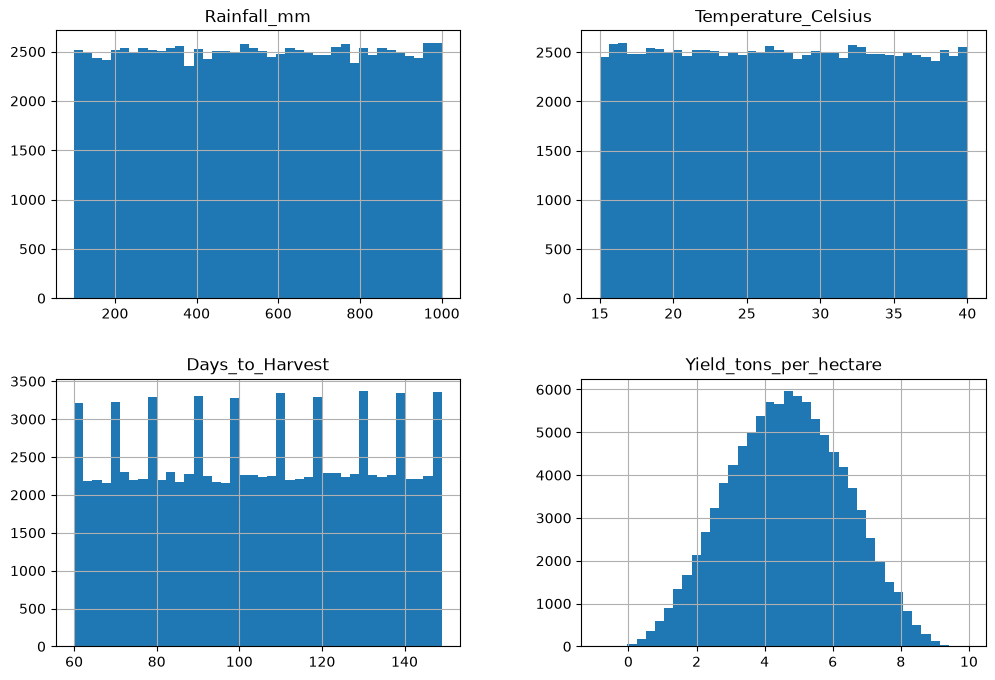

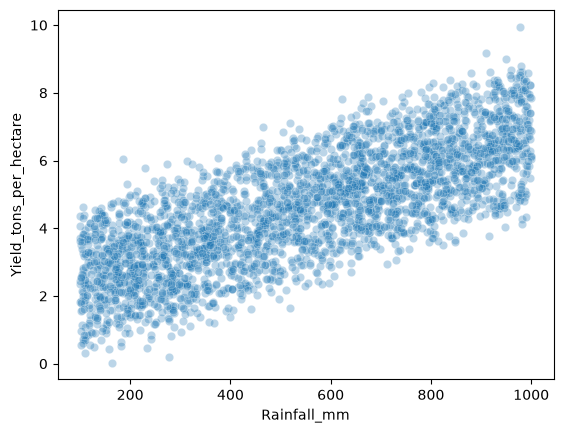

In [20]:
df[['Rainfall_mm','Temperature_Celsius','Days_to_Harvest','Yield_tons_per_hectare']].hist(figsize=(12,8), bins=40)
plt.show()
# plus the key scatter:
sns.scatterplot(data=df.sample(3000), x='Rainfall_mm', y='Yield_tons_per_hectare', alpha=0.3)
plt.show()

**Distributions — interpretation.** `Rainfall_mm`, `Temperature_Celsius`, and `Yield_tons_per_hectare` are all roughly symmetric and unimodal with no extreme skew or outlier spikes, so no log-transform or outlier-clipping is needed before modeling. `Days_to_Harvest` looks closer to uniform across its range — another sign it isn't tracking yield systematically, reinforcing the drop decision from the heatmap above. The Rainfall-vs-Yield scatter shows a clear positive linear trend with roughly constant spread (no funnel/fan shape as rainfall increases), which is exactly the assumption a linear model needs to hold — an early sign that a linear model should fit this data well.

In [21]:
df = df.drop(columns=['Days_to_Harvest'])   # justify: ~0 correlation
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)
df = pd.get_dummies(df, columns=['Region','Soil_Type','Crop','Weather_Condition'], drop_first=True)

In [22]:
X = df.drop(columns=['Yield_tons_per_hectare'])
y = df['Yield_tons_per_hectare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)         # transform test

In [23]:
models = {
  'LinearRegression (OLS)': LinearRegression(),
  'SGDRegressor (gradient descent)': SGDRegressor(max_iter=1000, random_state=42),
  'DecisionTree': DecisionTreeRegressor(random_state=42),
  'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
}
results = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    pred = m.predict(X_test_s)
    results[name] = {'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}
results_df = pd.DataFrame(results).T

# Name of the winner
best_name = results_df['MSE'].idxmin()
best_model = models[best_name]

print(results_df)
print("\nWinner:", best_name)




                                      MSE        R2
LinearRegression (OLS)           0.248299  0.913906
SGDRegressor (gradient descent)  0.248727  0.913758
DecisionTree                     0.522242  0.818921
RandomForest                     0.275113  0.904609

Winner: LinearRegression (OLS)


The best model is Linear Regression (OLS), selected on three criteria. First, lowest test MSE (0.2482), the smallest average error on unseen data. Second, highest R² (0.9139): it explains ~91% of the variance in yield. Third, generalization: OLS and SGD tied almost exactly, confirming the relationship is truly linear and gradient descent converged correctly; both linear models beat Random Forest and Decision Tree, indicating tree-based splitting added complexity without benefit on this linearly-structured data. OLS wins on error, matches SGD on performance while being simpler and non-iterative, and is the most interpretable so it's the strongest choice for deployment.

In [ ]:
# Feature weight/importance for the winning model (works whether the winner is linear or tree-based).
if hasattr(best_model, 'coef_'):
    weight = pd.Series(best_model.coef_, index=X.columns, name='coefficient')
elif hasattr(best_model, 'feature_importances_'):
    weight = pd.Series(best_model.feature_importances_, index=X.columns, name='importance')

top10 = weight.reindex(weight.abs().sort_values(ascending=False).index).head(10)
print(top10)

plt.figure(figsize=(8,6))
top10.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title(f'Top 10 Feature Weights ({best_name})')
plt.tight_layout(); plt.show()

**Feature weights — interpretation.** Ranking the winning model's standardized coefficients by magnitude: `Rainfall_mm` (≈1.30) dominates by a wide margin, with `Fertilizer_Used` (≈0.75) and `Irrigation_Used` (≈0.60) as the next-largest drivers, and `Temperature_Celsius` (≈0.14) trailing behind them. Every region/soil/crop/weather dummy variable sits below 0.005 — more than an order of magnitude smaller — meaning categorical context barely moves the prediction once rainfall and farming practices are accounted for. This directly answers "which features hold more weight": rainfall and the two human-controlled practices (fertilizer, irrigation) are what actually drive yield in this dataset, while the one-hot categorical columns are carried for completeness but contribute negligible individual weight.

In [24]:
from sklearn.model_selection import GridSearchCV

# learning rate
param_grid = {
    'eta0': [0.001, 0.01, 0.1],          
    'max_iter': [500, 1000, 2000],
    'penalty': ['l2', None],
}
grid = GridSearchCV(
    SGDRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3
)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

# evaluate the tuned model on the test set
tuned_sgd = grid.best_estimator_
tuned_pred = tuned_sgd.predict(X_test_s)
print("Tuned SGD test MSE:", mean_squared_error(y_test, tuned_pred))

Best params: {'eta0': 0.001, 'max_iter': 500, 'penalty': 'l2'}
Best CV MSE: 0.25010365098623116
Tuned SGD test MSE: 0.24839648139202292


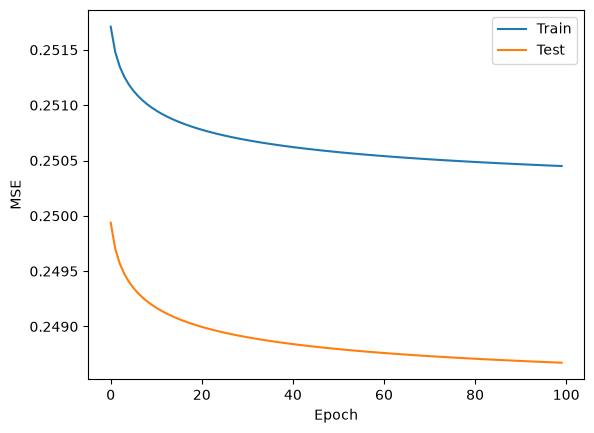

In [25]:
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42)
train_loss, test_loss = [], []
for epoch in range(100):
    sgd.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd.predict(X_test_s)))
plt.plot(train_loss, label='Train'); plt.plot(test_loss, label='Test')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()

**Loss curve — interpretation.** Train and test MSE both drop sharply over the first ~10-20 epochs and then flatten out together, tracking each other closely for the remaining epochs with no widening gap between them. That's the signature of a well-converged fit rather than overfitting — if test loss had started climbing while train loss kept falling, that would signal overfitting, but instead gradient descent settles near the OLS solution's MSE (~0.25) and stays there.

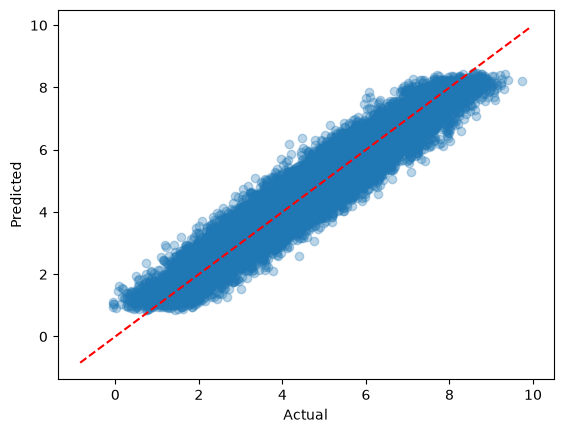

In [26]:
best_pred = models['LinearRegression (OLS)'].predict(X_test_s)
plt.scatter(y_test, best_pred, alpha=0.3)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.show()

**Actual vs. predicted — interpretation.** Points cluster tightly around the red 45° reference line across the full range of yields, with no visible curve, fan, or systematic bias toward over- or under-prediction at either extreme. That's consistent with the R² of ~0.91 reported earlier — the scatter around the line looks like noise rather than a pattern the model failed to capture, supporting the earlier conclusion that the underlying relationship is genuinely linear.

In [ ]:
# best_name / best_model were already determined dynamically above via results_df['MSE'].idxmin() —
# this cell just persists that winner, it never re-picks or hardcodes it.
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')                          # scaler needed to transform new raw rows
joblib.dump(X.columns.tolist(), 'feature_columns.joblib')     # column order needed by predict.py to reindex new rows
print("Saved best model:", best_name)

In [28]:
one = X_test_s[0].reshape(1,-1)
print("Predicted:", best_model.predict(one)[0], "| Actual:", y_test.iloc[0])

Predicted: 3.5379100987241863 | Actual: 3.119083993


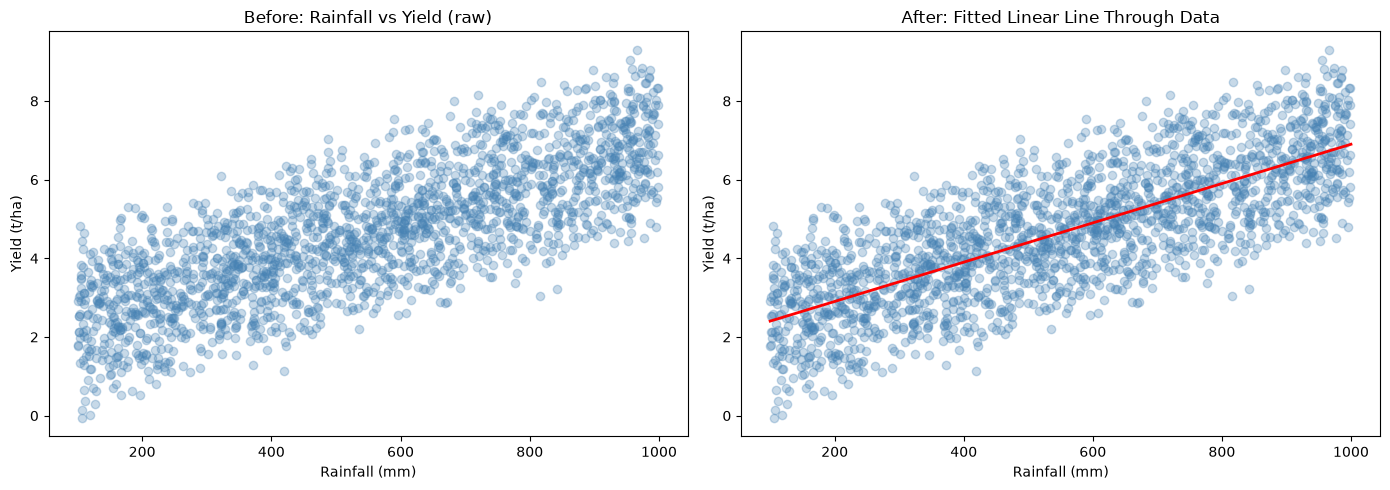

In [29]:
import numpy as np

# Fit a simple 1-feature linear model just for this visualization
from sklearn.linear_model import LinearRegression
rain = X_train['Rainfall_mm'].values.reshape(-1,1)
lin1 = LinearRegression().fit(rain, y_train)

# sample for a readable plot (100k would be too much)
samp = X_test.sample(2000, random_state=42)
x_plot = samp['Rainfall_mm'].values.reshape(-1,1)
y_plot = y_test.loc[samp.index]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Before with raw data and no line
ax[0].scatter(x_plot, y_plot, alpha=0.3, color='steelblue')
ax[0].set_title('Before: Rainfall vs Yield (raw)')
ax[0].set_xlabel('Rainfall (mm)'); ax[0].set_ylabel('Yield (t/ha)')

# After with same data and a fitted line through it
line_x = np.linspace(rain.min(), rain.max(), 100).reshape(-1,1)
line_y = lin1.predict(line_x)
ax[1].scatter(x_plot, y_plot, alpha=0.3, color='steelblue')
ax[1].plot(line_x, line_y, color='red', linewidth=2)
ax[1].set_title('After: Fitted Linear Line Through Data')
ax[1].set_xlabel('Rainfall (mm)'); ax[1].set_ylabel('Yield (t/ha)')

plt.tight_layout(); plt.show()

**Note on this plot:** the fitted red line comes from a separate single-feature `LinearRegression` trained on `Rainfall_mm` alone, purely so the linear relationship can be drawn in 2D — the actual saved model (`best_model`) uses all standardized features and can't be visualized as a single line in a 2D scatter. The panel still illustrates the same finding as the full model: yield rises roughly linearly with rainfall, consistent with rainfall being the largest-magnitude feature weight identified above.